In [11]:
import os, sys
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

cwd = os.getcwd()

file =  'FR0000073272_FOB_CNN_optimization.log'
#'FR0000073272_OHLCV_CNN_optimization.log'

In [12]:
#optuna.logging.get_logger("optuna").addHandler(logging.StreamHandler(sys.stdout))
STUDY_NAME = 'FR0000073272_FOB_CNN_optuna_study'
DB_PATH = os.path.join(cwd, file)
storage = optuna.storages.JournalStorage(optuna.storages.journal.JournalFileBackend(DB_PATH))

study = optuna.load_study(storage=storage, study_name=STUDY_NAME)

C:\Users\Utilisateur\anaconda3\lib\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [3, 3] which is of type list.
  warnings.warn(message)
C:\Users\Utilisateur\anaconda3\lib\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [5, 5] which is of type list.
  warnings.warn(message)
C:\Users\Utilisateur\anaconda3\lib\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [7, 7] which is of type list.
  warnings.warn(message)


In [13]:
df = study.trials_dataframe()
df['params_kernel_size'] = df['params_kernel_size'].apply(lambda x: x[0])
display(df.columns)
#display(study.best_params)
display(df)
display(list(set(df[:3]['state'].tolist())) == ['RUNNING','PRUNED'])
display(len(df[~df['value'].isna()]))

Index(['number', 'value', 'datetime_start', 'datetime_complete', 'duration',
       'params_batch_size', 'params_epochs', 'params_filters',
       'params_hidden_units', 'params_kernel_size', 'params_num_layers',
       'params_num_layers_Conv', 'state'],
      dtype='object')

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_epochs,params_filters,params_hidden_units,params_kernel_size,params_num_layers,params_num_layers_Conv,state
0,0,NaN,2025-04-30 05:40:40.710832,2025-04-30 10:24:10.329982,0 days 04:43:29.619150,32,500,64,128,3,2,1,PRUNED
1,1,1.000079,2025-04-30 05:57:28.727183,2025-04-30 12:28:49.379324,0 days 06:31:20.652141,64,100,32,64,7,1,2,COMPLETE
2,2,NaN,2025-04-30 05:58:59.405312,2025-04-30 10:42:26.820564,0 days 04:43:27.415252,128,1000,64,32,7,2,1,PRUNED
3,3,NaN,2025-04-30 06:05:13.708823,2025-04-30 10:48:39.468120,0 days 04:43:25.759297,64,500,32,64,7,1,1,PRUNED
4,4,1.000313,2025-04-30 06:12:43.876590,2025-04-30 11:41:02.556415,0 days 05:28:18.679825,128,100,32,256,3,3,2,COMPLETE
5,5,0.999954,2025-04-30 06:16:00.310802,2025-05-01 00:16:10.841235,0 days 18:00:10.530433,128,500,32,64,3,3,2,COMPLETE
6,6,1.000133,2025-04-30 06:16:29.792313,2025-04-30 11:24:31.567385,0 days 05:08:01.775072,128,100,32,64,7,1,2,COMPLETE
7,7,0.999817,2025-04-30 06:22:53.292962,2025-04-30 11:19:00.139923,0 days 04:56:06.846961,32,100,32,32,5,3,1,COMPLETE
8,8,NaN,2025-04-30 06:47:15.023423,2025-04-30 11:30:44.746918,0 days 04:43:29.723495,32,1000,64,64,5,3,2,PRUNED
9,9,NaN,2025-04-30 07:01:06.318467,2025-04-30 11:44:33.556080,0 days 04:43:27.237613,64,1000,32,256,5,2,2,PRUNED


False

34

In [14]:
now = datetime.now()
test = df.loc[(df['state'] == 'COMPLETE') | 
              ((df['state'] == 'RUNNING') & (df['datetime_start'] > (now - timedelta(days=1))))]
display(test)

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_epochs,params_filters,params_hidden_units,params_kernel_size,params_num_layers,params_num_layers_Conv,state
1,1,1.000079,2025-04-30 05:57:28.727183,2025-04-30 12:28:49.379324,0 days 06:31:20.652141,64,100,32,64,7,1,2,COMPLETE
4,4,1.000313,2025-04-30 06:12:43.876590,2025-04-30 11:41:02.556415,0 days 05:28:18.679825,128,100,32,256,3,3,2,COMPLETE
5,5,0.999954,2025-04-30 06:16:00.310802,2025-05-01 00:16:10.841235,0 days 18:00:10.530433,128,500,32,64,3,3,2,COMPLETE
6,6,1.000133,2025-04-30 06:16:29.792313,2025-04-30 11:24:31.567385,0 days 05:08:01.775072,128,100,32,64,7,1,2,COMPLETE
7,7,0.999817,2025-04-30 06:22:53.292962,2025-04-30 11:19:00.139923,0 days 04:56:06.846961,32,100,32,32,5,3,1,COMPLETE
11,11,1.000266,2025-04-30 07:30:25.324715,2025-04-30 18:02:14.827337,0 days 10:31:49.502622,128,100,64,64,7,3,2,COMPLETE
16,16,1.000105,2025-04-30 10:03:07.229395,2025-04-30 15:52:35.392291,0 days 05:49:28.162896,64,100,32,128,7,1,2,COMPLETE
18,18,0.999999,2025-04-30 10:37:52.364245,2025-04-30 21:27:46.441436,0 days 10:49:54.077191,32,100,32,128,7,1,1,COMPLETE
20,20,0.999843,2025-04-30 10:49:04.512622,2025-04-30 15:01:15.211061,0 days 04:12:10.698439,64,100,32,128,3,2,2,COMPLETE
25,25,0.999885,2025-04-30 11:41:35.266125,2025-04-30 21:23:05.120188,0 days 09:41:29.854063,32,100,64,32,7,1,2,COMPLETE


In [15]:
display(df[~df['value'].isna()].sort_values('value')[:10])
display(df.iloc[:,:-1].corr())

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_epochs,params_filters,params_hidden_units,params_kernel_size,params_num_layers,params_num_layers_Conv,state
7,7,0.999817,2025-04-30 06:22:53.292962,2025-04-30 11:19:00.139923,0 days 04:56:06.846961,32,100,32,32,5,3,1,COMPLETE
20,20,0.999843,2025-04-30 10:49:04.512622,2025-04-30 15:01:15.211061,0 days 04:12:10.698439,64,100,32,128,3,2,2,COMPLETE
30,30,0.999866,2025-04-30 12:29:01.531748,2025-04-30 17:06:05.691512,0 days 04:37:04.159764,32,100,32,32,5,3,1,COMPLETE
25,25,0.999885,2025-04-30 11:41:35.266125,2025-04-30 21:23:05.120188,0 days 09:41:29.854063,32,100,64,32,7,1,2,COMPLETE
32,32,0.999919,2025-04-30 12:48:27.788165,2025-04-30 15:12:34.585280,0 days 02:24:06.797115,32,100,32,32,5,3,1,COMPLETE
29,29,0.999925,2025-04-30 12:09:45.333017,2025-04-30 15:53:26.280150,0 days 03:43:40.947133,128,100,32,64,3,2,2,COMPLETE
45,45,0.999935,2025-05-02 17:09:27.525926,2025-05-02 21:11:50.396111,0 days 04:02:22.870185,32,100,32,32,5,3,1,COMPLETE
36,36,0.999937,2025-04-30 14:46:43.844913,2025-04-30 18:43:00.811293,0 days 03:56:16.966380,32,100,32,32,5,3,2,COMPLETE
37,37,0.999937,2025-04-30 15:01:58.909331,2025-04-30 17:26:08.547901,0 days 02:24:09.638570,32,100,32,32,3,3,2,COMPLETE
5,5,0.999954,2025-04-30 06:16:00.310802,2025-05-01 00:16:10.841235,0 days 18:00:10.530433,128,500,32,64,3,3,2,COMPLETE


,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_epochs,params_filters,params_hidden_units,params_kernel_size,params_num_layers,params_num_layers_Conv
number,1.000000,0.002264,0.656655,-0.304156,-0.304222,-0.454424,-0.522267,-0.225689,-0.006629,-0.102160,0.194492,-0.283709
value,0.002264,1.000000,0.084683,0.080341,-0.099214,0.307690,-0.127544,0.153654,0.224676,0.196794,0.012689,0.021744
datetime_start,0.656655,0.084683,1.000000,-0.537311,-0.537405,-0.143087,-0.290507,-0.061579,0.330705,0.189933,-0.142147,-0.369523
datetime_complete,-0.304156,0.080341,-0.537311,1.000000,1.000000,-0.016214,0.129423,0.130225,-0.420158,-0.244574,0.041089,0.173357
duration,-0.304222,-0.099214,-0.537405,1.000000,1.000000,-0.016194,0.129453,0.130224,-0.420172,-0.244581,0.041105,0.173394
params_batch_size,-0.454424,0.307690,-0.143087,-0.016214,-0.016194,1.000000,0.197453,0.231920,0.063156,0.270447,-0.162962,0.104608
params_epochs,-0.522267,-0.127544,-0.290507,0.129423,0.129453,0.197453,1.000000,0.328793,0.177473,-0.073066,-0.155339,0.097913
params_filters,-0.225689,0.153654,-0.061579,0.130225,0.130224,0.231920,0.328793,1.000000,-0.100028,0.263130,-0.086258,-0.244084
params_hidden_units,-0.006629,0.224676,0.330705,-0.420158,-0.420172,0.063156,0.177473,-0.100028,1.000000,-0.119544,-0.160298,0.095028
params_kernel_size,-0.102160,0.196794,0.189933,-0.244574,-0.244581,0.270447,-0.073066,0.263130,-0.119544,1.000000,-0.359840,-0.240850


In [14]:
optuna.visualization.plot_param_importances(study)

In [15]:
optuna.visualization.plot_optimization_history(study)

<Axes: ylabel='Frequency'>

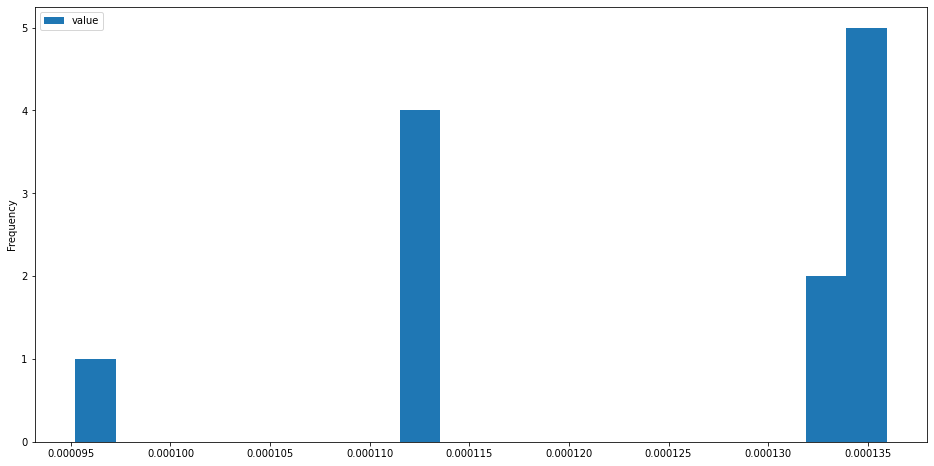

In [16]:
study.trials_dataframe()[['value']].plot.hist(bins=20, figsize=(16,8))
#count_df.loc[count_df['value'] < 0.00008, 'value'].plot.hist(bins=20, figsize=(16,8))

In [17]:
count = df[~df['value'].isna()].sort_values('value')#[:50]
#count['params_kernel_size'] = count['params_kernel_size'].apply(lambda x: x[0])

count_df = pd.DataFrame()

for _, chunk in count.groupby(['params_batch_size', 'params_epochs', 
                       'params_filters', 'params_hidden_units', 
                       'params_kernel_size', 'params_num_layers', 
                       'params_num_layers_Conv', 'state'
                      ]):
    
    chunk['duration'] = chunk['duration'].median()
    chunk['value'] = chunk['value'].median()
    chunk['number'] = len(chunk)
    chunk['std'] = chunk['value'].std()
    count_df = pd.concat([count_df, chunk.iloc[[0]]])

count_df[['rank_duration','rank_value']] = count_df[['duration','value']].rank()
count_df['rank_number'] = count_df['number'].rank(ascending=False)
count_df['rank_global'] = count_df[['rank_duration','rank_value','rank_number']].mean(axis=1)
display(count_df)
display(count_df[count_df['rank_global'] == count_df['rank_global'].min()])

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_epochs,params_filters,params_hidden_units,params_hidden_units_LSTM,params_kernel_size,params_num_layers,params_num_layers_Conv,params_num_layers_LSTM,state,std,rank_duration,rank_value,rank_number,rank_global
5,1,0.000133,2025-05-05 05:44:47.053475,2025-05-05 06:15:38.703656,0 days 00:30:51.650181,32,100,32,128,32,3,1,1,2,COMPLETE,NaN,4.0,3.0,5.5,4.166667
9,1,0.000136,2025-05-06 15:46:13.127057,2025-05-06 16:21:57.304337,0 days 00:35:44.177280,32,100,64,32,16,5,3,1,1,COMPLETE,NaN,5.0,9.0,5.5,6.500000
2,1,0.000136,2025-05-03 19:53:17.873280,2025-05-03 21:30:43.901295,0 days 01:37:26.028015,32,500,32,32,16,5,2,2,2,COMPLETE,NaN,7.0,6.0,5.5,6.166667
1,1,0.000136,2025-05-02 15:23:07.450816,2025-05-02 18:47:01.712092,0 days 03:23:54.261276,32,1000,32,64,32,5,2,2,2,COMPLETE,NaN,9.0,7.0,5.5,7.166667
12,4,0.000113,2025-05-09 07:03:21.994549,2025-05-09 07:27:01.814488,0 days 00:22:15.898051500,64,100,32,256,64,5,1,1,1,COMPLETE,0.0,3.0,2.0,1.0,2.000000
6,1,0.000095,2025-05-05 17:37:31.037419,2025-05-05 17:56:16.736677,0 days 00:18:45.699258,64,100,32,256,64,5,1,2,1,COMPLETE,NaN,2.0,1.0,5.5,2.833333
3,1,0.000136,2025-05-04 01:22:53.079235,2025-05-04 04:22:55.088553,0 days 03:00:02.009318,64,500,64,64,16,3,2,1,2,COMPLETE,NaN,8.0,8.0,5.5,7.166667
14,1,0.000135,2025-05-11 18:45:49.455095,2025-05-11 19:01:03.723661,0 days 00:15:14.268566,128,100,32,256,64,5,3,2,1,COMPLETE,NaN,1.0,5.0,5.5,3.833333
7,1,0.000133,2025-05-05 21:54:42.733024,2025-05-05 22:45:26.966911,0 days 00:50:44.233887,128,500,32,128,32,5,1,2,2,COMPLETE,NaN,6.0,4.0,5.5,5.166667


,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_epochs,params_filters,params_hidden_units,params_hidden_units_LSTM,params_kernel_size,params_num_layers,params_num_layers_Conv,params_num_layers_LSTM,state,std,rank_duration,rank_value,rank_number,rank_global
12,4,0.000113,2025-05-09 07:03:21.994549,2025-05-09 07:27:01.814488,0 days 00:22:15.898051500,64,100,32,256,64,5,1,1,1,COMPLETE,0.0,3.0,2.0,1.0,2.0


<Axes: xlabel='index'>

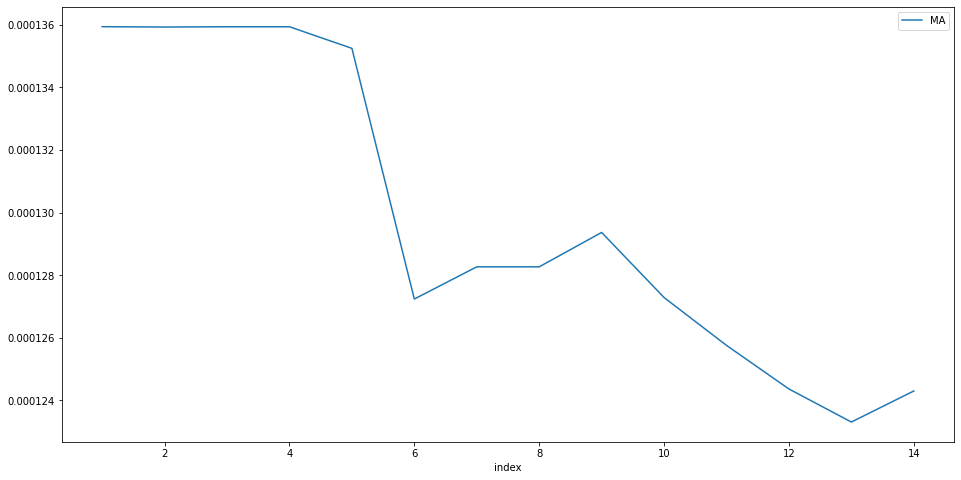

In [18]:
df_m = df.copy()
df_m = df_m[df_m['value'] < 0.00008]
df_m = df_m[~df_m['value'].isna()]
df['value'] = pd.to_numeric(df['value'], errors='coerce')
df_m['MA'] = df['value'].rolling(50, min_periods=1).mean()
df_m = df_m.reset_index(drop=True)
df_m['index'] = df_m.index
df_m.plot.line(x='index', y='MA', figsize=(16,8))